# Deep Learning for NLP

**Deep Learning** is a type of Machine Learning that uses **Neural Networks with multiple layers** to learn patterns from data.

Deep Learning can be used in NLP tasks such as:
- Text Classification
- Sentiment Analysis
- Question Answering

In this lab, we will build a **deep learning model** to classify Yelp restaurant reviews as:

- **0 = Negative**
- **1 = Positive**

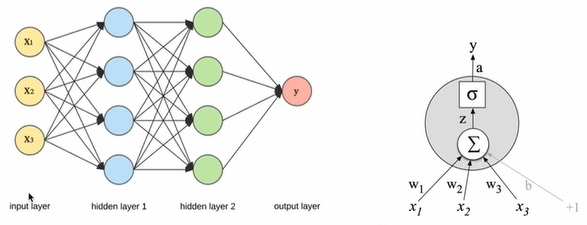

**every neurons, take weights of prevous layer outputs, multipling inputs (x1,x2...)with weights(w1,w2....) and taking the sum**

**the result of that sum is z, then this z input into activation functions, ex:sigmoid
then these neurons output go to next layer and same thing happens, final output will be 0 or 1 negtive or postive (sentiment analysis)**

<img src="https://drive.google.com/uc?export=view&id=1rUaLO1wEOcUZ10Kwd0nUvS3jQzrqoOcI" width="550">
<img src="https://drive.google.com/uc?export=view&id=1XKPTKwxmIpP5cZIkDajlai6aI9jUX-C8" width="400">

## 1. Load the Yelp Dataset

Each row contains:

- a restaurant review
- its sentiment label


In [1]:
import pandas as pd

df = pd.read_csv("07-yelp-dataset.txt", sep="\t", names=["review", "label"])

print("Number of reviews:", len(df))
df.head()

Number of reviews: 1000


,review,label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [2]:
print(df["label"].value_counts()) # balanced dataset

label
1    500
0    500
Name: count, dtype: int64


## 2. Preprocessing the Dataset

In [3]:
import re  # regular expression

def preprocess_text(text):

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

    # preprosses the dataset
df["review"] = df["review"].apply(preprocess_text)
df.head()

,review,label
0,wow loved this place,1
1,crust is not good,0
2,not tasty and the texture was just nasty,0
3,stopped by during the late may bank holiday of...,1
4,the selection on the menu was great and so wer...,1


## 3. Split the Data

We divide the dataset into:

- **80% training data** — used to train the model
- **20% testing data** — used to evaluate the model

`stratify=y` keeps the proportion of positive and negative reviews similar in both sets.

In [4]:
from sklearn.model_selection import train_test_split

X = df["review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
# random_state=42: split the dataset the same way for every run, reproduceability 

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 800
Testing reviews: 200


## 4. Convert Text to TF-IDF Vectors

A neural network cannot directly understand text.

**TF-IDF converts each review into a vector of numbers.**


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000, lowercase=True) 
# TfidfVectorizer object. max_features=1000: most importnt 1000 feature

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape) # (800, 1000): 800 reviews, with most important 1000 features 
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (800, 1000)
Testing TF-IDF shape: (200, 1000)


## 5. Convert the Data to PyTorch Tensors

PyTorch neural networks work with **tensors**.

In [6]:
%pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import torch
import torch.nn as nn

# Convert TF-IDF data to PyTorch tensors, to input it into neural networks 
X_train_tensor = torch.FloatTensor(X_train_tfidf.toarray())
X_test_tensor = torch.FloatTensor(X_test_tfidf.toarray())
# X_train_tfidf: is a sparse matrix, has a lot of zeros. convert it into an array, 
# then torch.FloatTensor convert the array to float tensor 

# reshape y_train, for netowrk to understand it.
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)

## 6. Build a Simple Neural Network

Our network has:

1. **Input layer** — receives the TF-IDF features
2. **Hidden layer** — learns useful patterns
3. **ReLU activation** — adds non-linearity
4. **Output layer** — produces one value for binary classification

We do **not** put `Sigmoid` inside the model because `BCEWithLogitsLoss` applies it internally in a numerically stable way.

In [8]:
input_size = X_train_tensor.shape[1] # index 1: features
# torch.size([800, 1000]) 800 reviwes, in 1000 feature
# features are the input to network

model = nn.Sequential(
    nn.Linear(input_size, 64),   # Input layer
    nn.ReLU(),                   # activation function

    nn.Linear(64, 32),           # Hidden layer, take 64 neurons, output 32 neurons
    nn.ReLU(),

    nn.Linear(32, 1)             # Output layer, take 32 neurons, output 1 -> the sentiment 
)

print(model)

Sequential(
  (0): Linear(in_features=1000, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


## 7. Choose the Loss Function and Optimizer

- **BCEWithLogitsLoss** is used for binary classification.
To measure the model’s mistakes.
- **Adam** is responsible for changing the model's weights so that the loss becomes smaller.

In [9]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # learning rate, supposed to be small

## 8. Train the Neural Network

One **epoch** means the model has seen the full training dataset once.

For every epoch:

1. Make predictions
2. Calculate the loss
3. Calculate gradients with backpropagation
4. Update the weights

In [10]:
epochs = 10 # train with dataset for 10 times

for epoch in range(epochs):
    model.train()

    # 1. Forward pass
    outputs = model(X_train_tensor)

    # 2. Calculate loss
    loss = loss_function(outputs, y_train_tensor) # (model predections, true labels)

    # 3. Backpropagation. from output layer to input layer
    loss.backward()

    # 4. Update model weights
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

Epoch 5/10 - Loss: 0.6073
Epoch 10/10 - Loss: 0.3403


## 9. Evaluate the Model

The model outputs raw scores called **logits**.

We apply `sigmoid` to convert them to probabilities between 0 and 1.

- Probability **≥ 0.5 → Positive (1)**
- Probability **< 0.5 → Negative (0)**

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()

with torch.no_grad():
    test = model(X_test_tensor)
    test_probabilities = torch.sigmoid(test) # activation function, converts to 0 or 1.
    predictions = (test_probabilities >= 0.5).int().numpy().flatten() # 1D array

accuracy = accuracy_score(y_test, predictions) # (actual, model predections)

print(f"Test Accuracy: {accuracy:.3f}")

Test Accuracy: 0.745


## 10. Classification Report and Confusion Matrix

The classification report shows:

- **Precision**
- **Recall**
- **F1-score**

The confusion matrix shows how many reviews were classified correctly and incorrectly.

In [12]:
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=["Negative", "Positive"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.84      0.76        96
    Positive       0.82      0.65      0.73       104

    accuracy                           0.74       200
   macro avg       0.76      0.75      0.74       200
weighted avg       0.76      0.74      0.74       200

Confusion Matrix:
[[81 15]
 [36 68]]


## Task 1 – Represent Reviews Using Word2Vec

In the previous part of the lab, TF-IDF was used to convert each review into numerical features.
Now, use Word2Vec instead.

Requirements:
Tokenize the training and testing reviews.
Train a Word2Vec model using the training reviews.
Use:
vector_size = 200
window = 5
min_count = 1
sg = 1

Convert each review into a single vector.
Convert the resulting vectors into PyTorch tensors.


In [13]:
import pandas as pd
import nltk
import numpy as np
import gensim
from nltk.tokenize import word_tokenize

In [14]:
# Tokenize the training and testing reviews. 
from nltk.tokenize import word_tokenize

X_train_tokens = [word_tokenize(review) for review in X_train]
X_test_tokens = [word_tokenize(review) for review in X_test]

In [15]:
# Train a Word2Vec model using the training reviews.
Skip_gram_model = gensim.models.Word2Vec(X_train_tokens, min_count = 1, vector_size = 200, window = 5, sg = 1)

In [16]:
# Convert each review into a single vector.using Word2Vec

X_train_vectors = []

for review in X_train_tokens:
    vectors = [ Skip_gram_model.wv[word] for word in review ]
    review_vector = np.mean(vectors, axis=0)
    X_train_vectors.append(review_vector)
    

What is happening?

For a review like: ["This", "movie", "was", "great"]

Word2Vec gives:

"This"  → 200 numbers

"movie" → 200 numbers

"was"   → 200 numbers

"great" → 200 numbers

Then:

np.mean(vectors, axis=0) averages those vectors → one vector containing 200 numbers.

So the final structure is:

Review 1 → [200 numbers]

Review 2 → [200 numbers]

Review 3 → [200 numbers]

This is exactly what "Convert each review into a single vector" means.

In [17]:
# Convert each review into a single vector. Test reviews

X_test_vectors = []

for review in X_test_tokens:
    vectors = [Skip_gram_model.wv[word] for word in review 
               if word in Skip_gram_model.wv]
    
    review_vector = np.mean(vectors, axis=0)
    X_test_vectors.append(review_vector)

The problem is that Word2Vec was trained only on X_train_tokens, so some words that appear in the test set don't exist in its vocabulary.

For example: NOW appears in X_test_tokens, but not in X_train_tokens

This causes the KeyError.

Fix: Simply skip words that aren't in the Word2Vec vocabulary:

In [18]:
# Convert the resulting vectors into PyTorch tensors.

# Since X_train_vectors and X_test_vectors are lists of NumPy arrays, convert dirctaly without .toarray()
X_train_tensor = torch.tensor(X_train_vectors, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_vectors, dtype=torch.float32)

y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)

C:\Users\N\AppData\Local\Temp\ipykernel_12664\2392499915.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:255.)
  X_train_tensor = torch.tensor(X_train_vectors, dtype=torch.float32)


## Task 2 – Build a Different Neural Network

Use the Word2Vec vectors from Task 1 as the input to a new neural network.
Your network must contain:
An input layer
Three hidden layers
ReLU activation functions
One output neuron
Use the following architecture:

Input
   
   ↓

128 neurons
   
   ↓

64 neurons
   
   ↓

32 neurons
   
   ↓

1 output neuron

Train the model using:
, BCEWithLogitsLoss
, Adam optimizer
, Learning rate = 0.001
, 15 epochs.
Then calculate the test accuracy.

In [19]:
# new neural network.
input_size = X_train_tensor.shape[1] 

model = nn.Sequential(
    nn.Linear(input_size, 128),   # Input layer
    nn.ReLU(),                   # activation function

    nn.Linear(128, 64),           # Hidden layer, 
    nn.ReLU(),

    nn.Linear(64, 32),           # Hidden layer, 
    nn.ReLU(),

    nn.Linear(32, 1)             # Output layer, take 32 neurons, output 1 -> the sentiment 
)

print(model)

Sequential(
  (0): Linear(in_features=200, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
)


In [20]:
# BCEWithLogitsLoss , Adam optimizer , Learning rate = 0.001

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 

In [21]:
# Train the model, with 15 epochs 

epochs = 15 

for epoch in range(epochs):
    model.train()

    # 1. Forward pass
    outputs = model(X_train_tensor)

    # 2. Calculate loss
    loss = loss_function(outputs, y_train_tensor) # (predections on train reviews, training labels)

    # 3. Backpropagation. 
    loss.backward()

    # 4. Update model weights
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

Epoch 5/15 - Loss: 0.6937
Epoch 10/15 - Loss: 0.6930
Epoch 15/15 - Loss: 0.6947


In [22]:
# calculate the test accuracy.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()

with torch.no_grad():
    test = model(X_test_tensor)
    test_probabilities = torch.sigmoid(test) # activation function, converts to 0 or 1.
    predictions = (test_probabilities >= 0.5).int().numpy().flatten() # 1D array

accuracy = accuracy_score(y_test, predictions) # (actual text labels, model predections)

print(f"Test Accuracy: {accuracy:.3f}")

Test Accuracy: 0.520
